# LeetCode #530: Minimum Absolute Difference in BST

https://leetcode.com/problems/minimum-absolute-difference-in-bst/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (all pairs)** | $O(n^2)$ | $O(n)$ |
| **Optimal: In-order Traversal ★** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### Brute Force (all pairs)
Collect all node values, then compare every pair to find the minimum difference. $O(n^2)$ pairs, each $O(1)$ comparison.

### Optimal: In-order Traversal ★
In-order traversal of a BST yields values in sorted (ascending) order. The minimum absolute difference between any two values in a sorted sequence is always between adjacent elements. Track the previous value during traversal and update the minimum difference at each step.

**Why this is better than Brute Force:** The BST's sorted property lets us check only $n-1$ adjacent pairs instead of all $O(n^2)$ pairs.

**Constraints:**
* The number of nodes in the tree is in the range $[2, 10^4]$
* $0 \le \text{Node.val} \le 10^5$


## Solutions

### C#

In [ ]:
public int GetMinimumDifference(TreeNode root) {
    int minDiff = int.MaxValue, prev = -1;
    void Traverse(TreeNode node) {
        if (node == null) return;
        Traverse(node.left);
        // In sorted order, minimum difference is between adjacent values
        if (prev != -1) minDiff = Math.Min(minDiff, node.val - prev);
        prev = node.val;
        Traverse(node.right);
    }
    Traverse(root);
    return minDiff;
}

### Python

In [ ]:
def get_minimum_difference(root) -> int:
    min_diff = float('inf')
    prev = -1

    def traverse(node):
        nonlocal min_diff, prev
        if not node:
            return
        traverse(node.left)
        # In sorted order, minimum difference is between adjacent values
        if prev != -1:
            min_diff = min(min_diff, node.val - prev)
        prev = node.val
        traverse(node.right)

    traverse(root)
    return min_diff

### Go

In [ ]:
import "math"

func getMinimumDifference(root *TreeNode) int {
    minDiff, prev := math.MaxInt32, -1
    var traverse func(*TreeNode)
    traverse = func(node *TreeNode) {
        if node == nil { return }
        traverse(node.Left)
        // In sorted order, minimum difference is between adjacent values
        if prev != -1 && node.Val-prev < minDiff { minDiff = node.Val - prev }
        prev = node.Val
        traverse(node.Right)
    }
    traverse(root)
    return minDiff
}

### Rust

In [ ]:
pub fn get_minimum_difference(root: Option<Box<TreeNode>>) -> i32 {
    fn traverse(node: &Option<Box<TreeNode>>, min_diff: &mut i32, prev: &mut i32) {
        if let Some(n) = node {
            traverse(&n.left, min_diff, prev);
            // In sorted order, minimum difference is between adjacent values
            if *prev != -1 { *min_diff = (*min_diff).min(n.val - *prev); }
            *prev = n.val;
            traverse(&n.right, min_diff, prev);
        }
    }
    let mut min_diff = i32::MAX;
    traverse(&root, &mut min_diff, &mut -1);
    min_diff
}

## Example Scenarios

**1. Common Case**
**Input:** `root = [4,2,6,1,3]`
In-order: 1,2,3,4,6. Adjacent differences: 1,1,1,2. Minimum = 1 (between 1–2 or 2–3 or 3–4).

**2. Slightly Complex**
**Input:** `root = [1,0,48,null,null,12,49]`
In-order: 0,1,12,48,49. Adjacent differences: 1,11,36,1. Minimum = 1 (between 48–49 or 0–1).

**3. Edge Case: Time Factor**
**Input:** Right-skewed tree `[1,null,2,null,...,null,n]` ($n = 10^4$)
In-order traversal visits all $n$ nodes in sequence 1,2,...,n. All adjacent differences are 1. The full traversal is needed before the minimum is confirmed — $O(n)$ steps.

**4. Edge Case: Space Factor**
**Input:** Perfectly balanced BST of height $h = \log n$
Recursion stack depth = $O(h) = O(\log n)$. For $n = 10^4$, only $\approx 14$ frames on the stack — constant compared to the $O(n)$ brute-force array.

**5. Almost-Impossible but Plausible**
**Input:** `root = [0, null, 100000]` (two nodes, max gap)
In-order: 0, 100000. Only one adjacent pair: difference = 100000. This is both the maximum and minimum difference. The correct answer 100000 is returned immediately after visiting the second node.


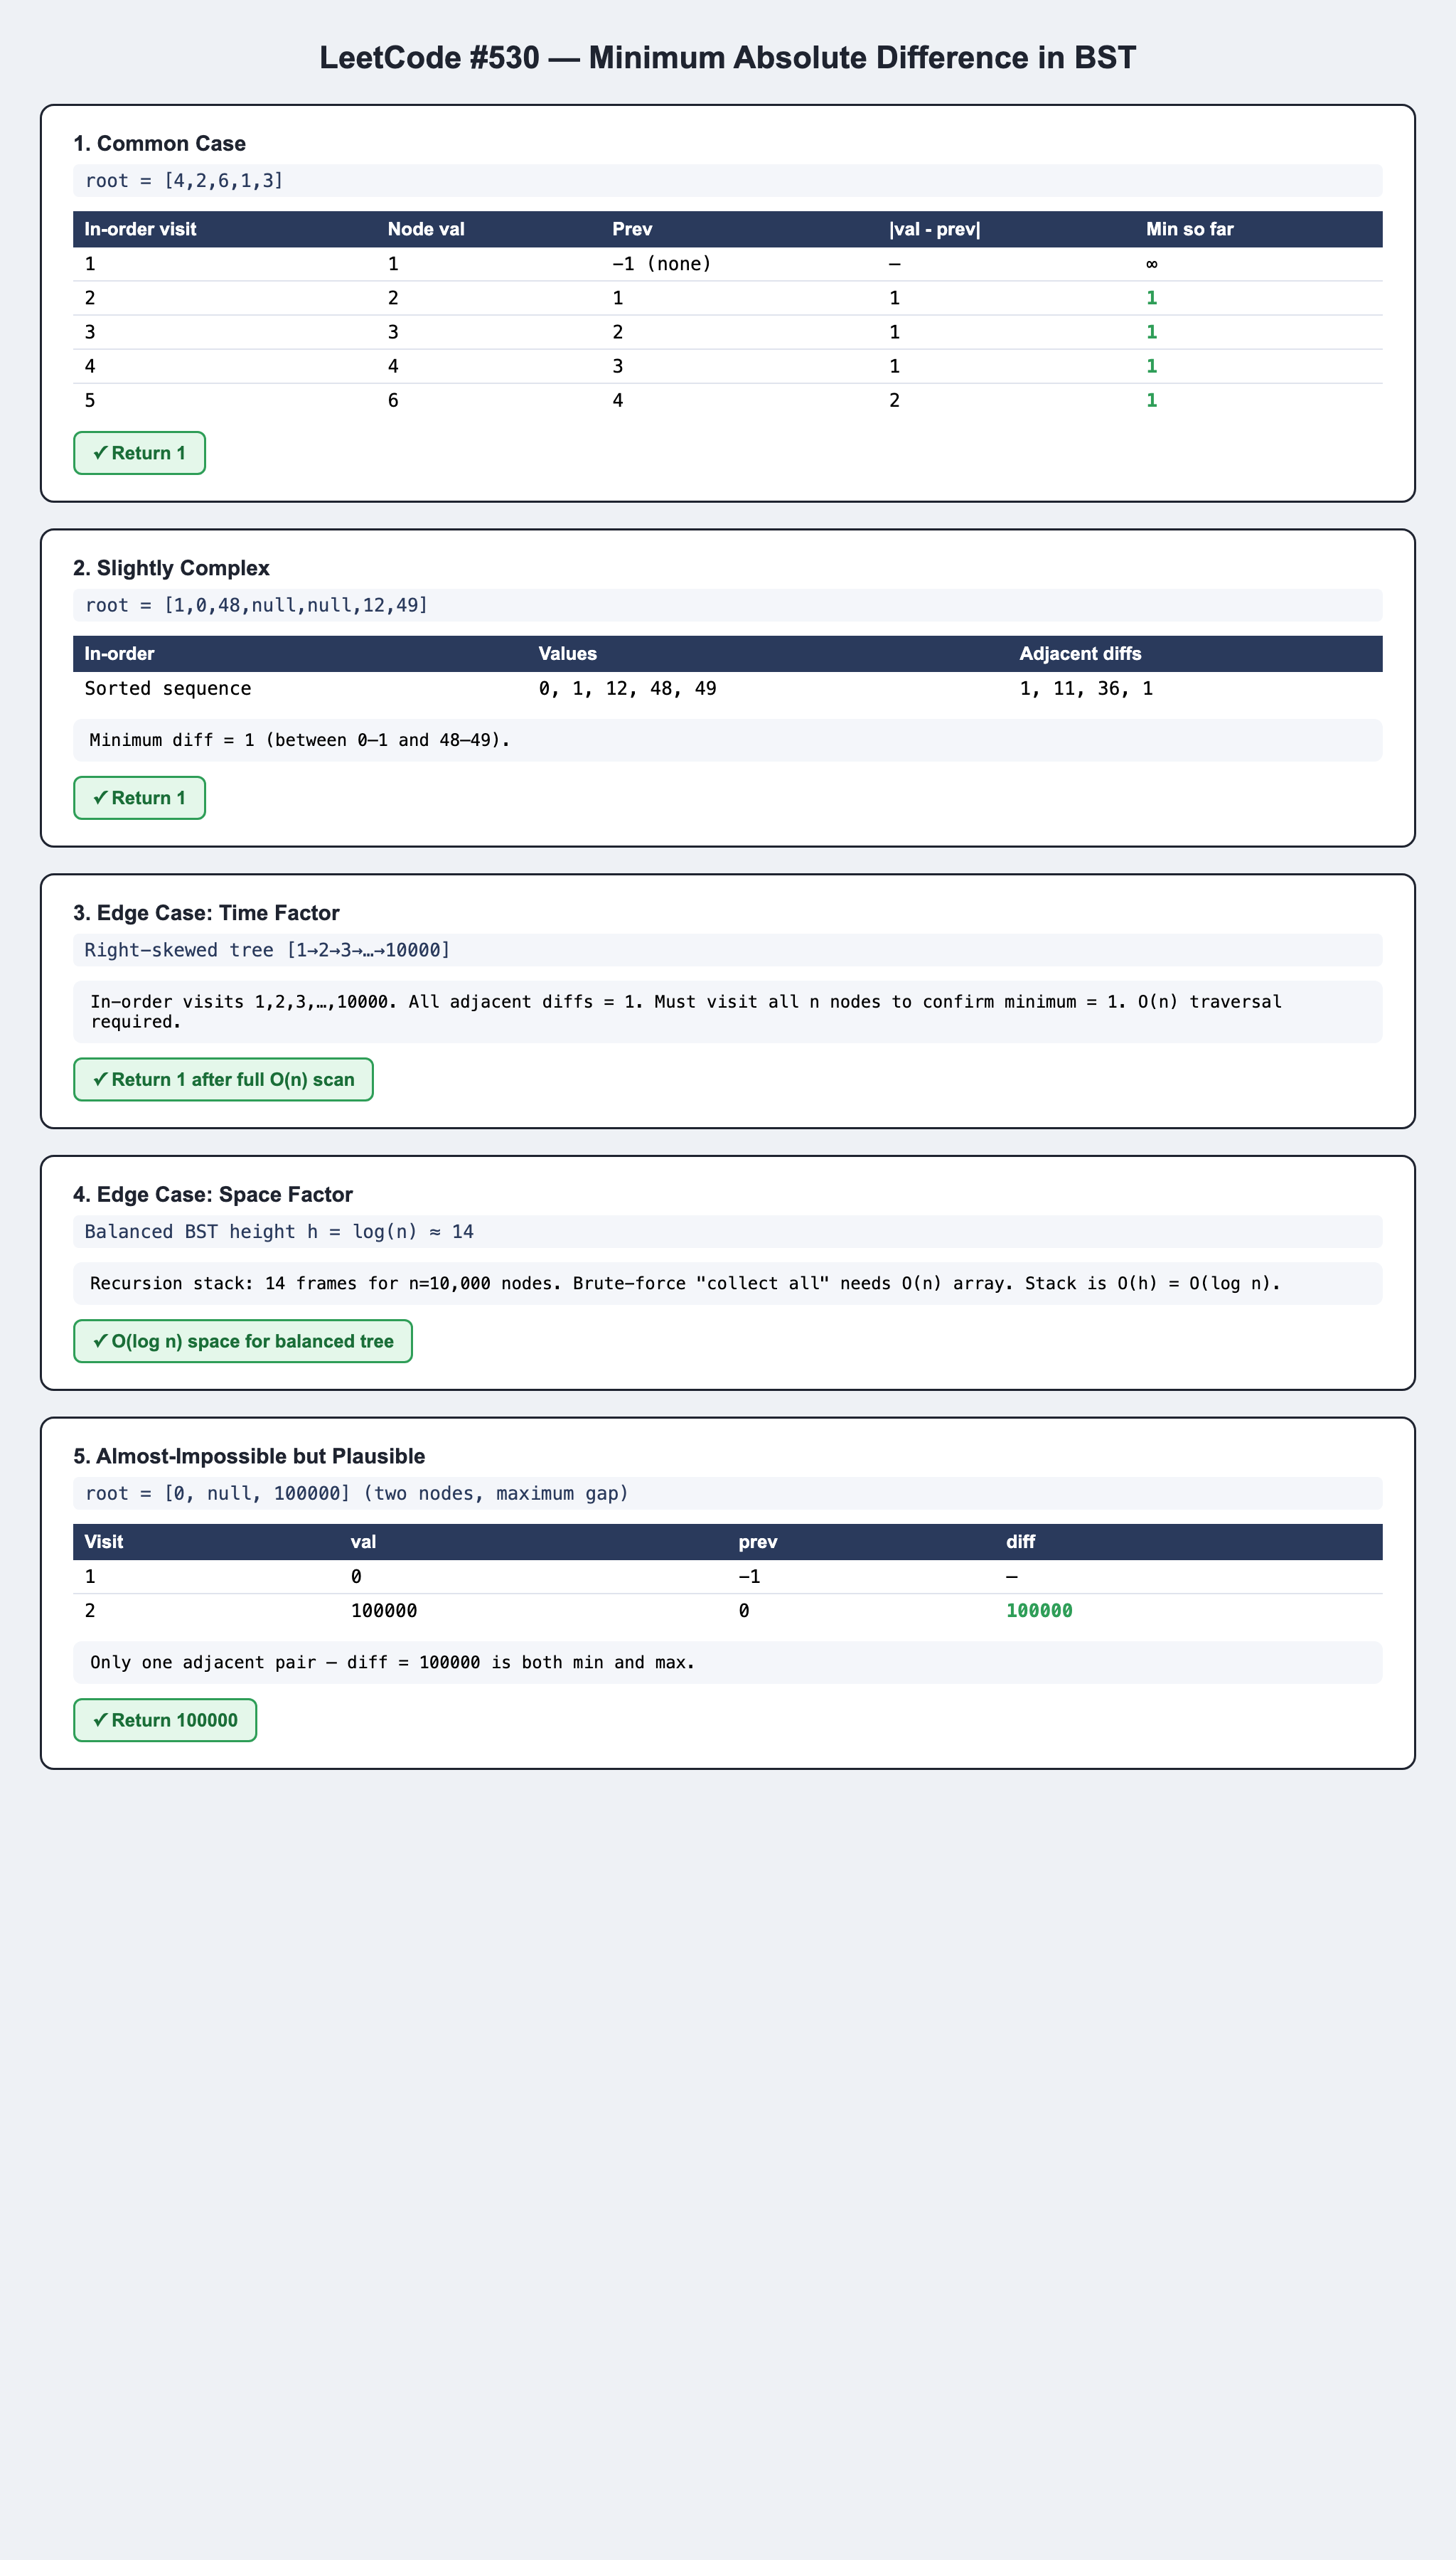